<a href="https://colab.research.google.com/github/lqi234488/my/blob/main/Transformer_%26_KV_Cache.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
#禁止使用：torch.nn.Transformer相關模組、torch.nn.MultiheadAttention、einops（強迫練習維度變換）。
#允許使用：torch.nn.Parameter、torch.nn.Linear（或直接用矩陣乘法）、torch.nn.Softmax、基礎的 Tensor 操作（reshape, transpose, matmul）

實作1 Position Embedding (Sinusoidal)

任務：不使用訓練式的 Embedding，要求學員根據公式實作正弦與餘弦位置編碼。
驗證：產出一張熱力圖（Heatmap），觀察不同位置之間的點積隨距離增加而下降。

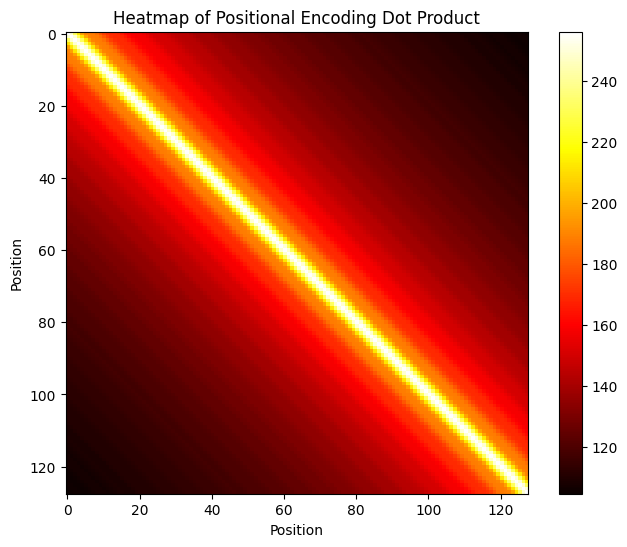

In [52]:
import numpy as np
import matplotlib.pyplot as plt

def get_sinusoidal_encoding(seq_len, d_model):
    # 建立一個 (seq_len, d_model) 的矩陣
    pe = np.zeros((seq_len, d_model))
    position = np.arange(seq_len)[:, np.newaxis]
    # 計算公式中的分母部分 (10000^(2i/d_model))
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    # 偶數索引填入 sin, 奇數索引填入 cos
    pe[:, 0::2] = np.sin(position * div_term)
    pe[:, 1::2] = np.cos(position * div_term)
    return pe

# 設定參數：序列長度 128，維度 512
seq_len, d_model = 128, 512
pe = get_sinusoidal_encoding(seq_len, d_model)

# 驗證：計算點積相似度 (Similarity = PE @ PE.T)
# 這會得到一個 (seq_len, seq_len) 的矩陣，代表位置 i 與 位置 j 的相似度
similarity = np.dot(pe, pe.T)

# 畫圖
plt.figure(figsize=(8, 6))
plt.imshow(similarity, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title("Heatmap of Positional Encoding Dot Product")
plt.xlabel("Position")
plt.ylabel("Position")
plt.show()

實作2 Feed-Forward Network (FFN)

任務：實作兩層線性層，中間夾一個 ReLU 或 GELU 激活函數。
驗證：檢查輸入與輸出的維度是否一致。

In [70]:
import torch
import torch.nn as nn
import math

class ManualMultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        # 允許使用 nn.Linear
        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x, past_kv=None):
        batch_size, seq_len, d_model = x.shape

        # 1. 投影
        q = self.q_linear(x).reshape(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        k = self.k_linear(x).reshape(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        v = self.v_linear(x).reshape(batch_size, seq_len, self.n_heads, self.d_k).transpose(1, 2)

        # 2. KV Cache 拼接邏輯 (實作 5 的核心)
        if past_kv is not None:
            past_k, past_v = past_kv
            k = torch.cat([past_k, k], dim=2) # 在 seq_len 維度拼接
            v = torch.cat([past_v, v], dim=2)

        present_kv = (k, v) # 回傳給下一輪使用

        # 3. 注意力計算 (這時 Q 的 seq_len=1, 但 K, V 的 seq_len 是累積的)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)

        # 注意：推論時如果只傳入最後一個 token，通常不需要 Causal Mask
        # 因為 Q 只有一個，它本來就看不到未來
        q_len = q.size(2)
        k_len = k.size(2)

        if q_len > 1: # 代表這是在處理一整串句子，必須防止偷看未來
          # 建立下三角遮罩 (確保矩陣大小跟當前的 scores 一致)
          mask = torch.tril(torch.ones(q_len, k_len)).to(x.device)
          # 把右上角填入負無限大
          scores = scores.masked_fill(mask == 0, float("-inf"))

        attn = torch.softmax(scores, dim=-1)
        context = torch.matmul(attn, v).transpose(1, 2).reshape(batch_size, seq_len, d_model)
        present_kv = (k, v) # 這是快取

        return self.out_proj(context), attn, present_kv

In [71]:
# 測試參數
batch_size = 2
seq_len = 10
d_model = 128
n_heads = 8

# 初始化模型
mha = ManualMultiHeadAttention(d_model, n_heads)

# 建立模擬輸入 (B, S, D)
x = torch.randn(batch_size, seq_len, d_model)

# 執行 Forward
output, attn,_ = mha(x)

# 驗證 1：輸出維度是否等於輸入維度
print(f"輸入維度: {x.shape}")
print(f"輸出維度: {output.shape}")
assert x.shape == output.shape, "❌ 維度不一致！"
print("✅ 維度檢查通過！")


輸入維度: torch.Size([2, 10, 128])
輸出維度: torch.Size([2, 10, 128])
✅ 維度檢查通過！


In [72]:
# 驗證 2：檢查 Softmax 是否正確歸一化
# 假設你的 attn 形狀是 (B, H, S, S)
# 我們檢查最後一個維度（對所有單字的注意力）加起來是否為 1
# 這裡 mha(x) 會回傳三個值
output, attn, _ = mha(x) # 注意這裡用三個變數接，最後一個緩存用不到就寫 _
sums = attn.sum(dim=-1)
print(f"Attention Sum (應接近 1.0): {sums[0, 0, 0].item()}")
assert torch.allclose(sums, torch.ones_like(sums)), "❌ Softmax 歸一化失敗！"
print("✅ 注意力權重檢查通過！")

Attention Sum (應接近 1.0): 1.0
✅ 注意力權重檢查通過！


實作3 Scaled Dot-Product Self-Attention

●任務：手動計算 $Q, K, V$ 矩陣乘法。

●挑戰：
實作 的縮放（Scale）。
實作 Causal Mask：手動產生一個下三角矩陣（torch.tril），將右上角填充為 -inf。

●驗證：給入一個句子，檢查輸出矩陣中，第 1 個 token 是否真的完全沒有參考到第 2 個 token 的資訊。

In [73]:
# 測試一個長度為 4 的序列
test_seq_len = 4
test_x = torch.randn(1, test_seq_len, d_model)
_, test_attn,_ = mha(test_x)

# 打印出第 1 個頭的注意力矩陣
# 這是一個 4x4 的矩陣
print("注意力矩陣 (應為下三角):")
print(test_attn[0, 0].detach().cpu().numpy().round(3))

注意力矩陣 (應為下三角):
[[1.    0.    0.    0.   ]
 [0.594 0.406 0.    0.   ]
 [0.358 0.363 0.279 0.   ]
 [0.267 0.319 0.241 0.173]]


實作4 Residual Connection (殘差連接) & Layer Norm (層歸一化)

●任務：將上述組件串接，實作 x + Sublayer(x)。

●挑戰：理解為何要先進行 Layer Norm（Pre-Norm）還是後進行（Post-Norm）。

●驗證：測試當輸入全為 0 時，殘差路徑是否能正確傳遞資訊。

In [74]:
import torch
import torch.nn as nn

# 1. 先定義好 FeedForward (確保名稱一致)
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.activation(self.linear1(x)))

# 2. 定義 TransformerBlock
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.attention = ManualMultiHeadAttention(d_model, n_heads)
        self.ffn = FeedForward(d_model, d_ff) # 這裡現在對得起來了！
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x, past_kv=None):
        # 注意力路徑 (Pre-Norm)
        attn_out, attn_weights, present_kv = self.attention(self.ln1(x), past_kv=past_kv)
        x = x + attn_out

        # 前饋網路路徑 (Pre-Norm)
        x = x + self.ffn(self.ln2(x))
        return x, attn_weights, present_kv

d_model = 128
block = TransformerBlock(d_model, n_heads=8, d_ff=512)
zero_input = torch.zeros(1, 1, d_model)

# 修正重點：用 "output, _" 來接球。
# "_" 代表我們暫時不需要用到回傳的 KV Cache
output, _, _ = block(zero_input)

print(f"輸入總和: {zero_input.sum().item()}")
print(f"輸出總和: {output.sum().item():.4f}") # 現在 output 是 Tensor 了，可以 sum()

if not torch.equal(output, zero_input):
    print("✅ 驗證成功：殘差路徑運作正常，資訊已成功傳遞！")

輸入總和: 0.0
輸出總和: -2.5404
✅ 驗證成功：殘差路徑運作正常，資訊已成功傳遞！


實作5 KV Cache 邏輯

●任務：撰寫一個 greedy_decode 函式，對比「全量重算」與「KV Cache」兩種模式。

●挑戰：

○在 Cache 模式下，每次只傳入最後一個 token 的向量。

○正確地將當前的 K, V 拼接（Concatenate）到舊的 Cache 矩陣中。

In [75]:
def greedy_decode(model, input_ids, max_len=5, use_cache=True):
    # 這裡簡化假設輸入已經是 Embedding 向量 (B, S, D)
    current_pos_vectors = input_ids

    past_kv = None
    generated_outputs = []
    print(f"--- 開始 {'Cache' if use_cache else '全量重算'} 模式 ---")

    for i in range(max_len):
        if use_cache:
            # 【Cache 模式】：只傳入「最後一個」產出的向量
            # 第一次傳全部，之後只傳最新的一筆
            step_input = current_pos_vectors[:, -1:, :] if i > 0 else current_pos_vectors
            output, _, past_kv = model(step_input, past_kv=past_kv)
        else:
            # 【全量重算模式】：每次都把「到目前為止」的所有字丟進去
            output, _, _ = model(current_pos_vectors)

        # 取得最後一個輸出的 token 向量 (模擬生成)
        next_token_vec = output[:, -1:, :]
        generated_outputs.append(next_token_vec)

        # 更新目前已有的序列
        current_pos_vectors = torch.cat([current_pos_vectors, next_token_vec], dim=1)

        print(f"Step {i+1}: 輸入序列長度 = {step_input.shape[1] if use_cache else current_pos_vectors.shape[1]}")

    return current_pos_vectors

In [76]:
import time

# 先執行全 0 驗證確保模型沒壞
output, _, _ = block(zero_input)

# 開始對比測試
start = time.time()
res_no_cache = greedy_decode(block, initial_input, max_len=20, use_cache=False)
print(f"⏱️ 全量重算總耗時: {time.time() - start:.4f}s")

start = time.time()
res_cache = greedy_decode(block, initial_input, max_len=20, use_cache=True)
print(f"🚀 KV Cache 總耗時: {time.time() - start:.4f}s")

--- 開始 全量重算 模式 ---
Step 1: 輸入序列長度 = 4
Step 2: 輸入序列長度 = 5
Step 3: 輸入序列長度 = 6
Step 4: 輸入序列長度 = 7
Step 5: 輸入序列長度 = 8
Step 6: 輸入序列長度 = 9
Step 7: 輸入序列長度 = 10
Step 8: 輸入序列長度 = 11
Step 9: 輸入序列長度 = 12
Step 10: 輸入序列長度 = 13
Step 11: 輸入序列長度 = 14
Step 12: 輸入序列長度 = 15
Step 13: 輸入序列長度 = 16
Step 14: 輸入序列長度 = 17
Step 15: 輸入序列長度 = 18
Step 16: 輸入序列長度 = 19
Step 17: 輸入序列長度 = 20
Step 18: 輸入序列長度 = 21
Step 19: 輸入序列長度 = 22
Step 20: 輸入序列長度 = 23
⏱️ 全量重算總耗時: 0.0340s
--- 開始 Cache 模式 ---
Step 1: 輸入序列長度 = 3
Step 2: 輸入序列長度 = 1
Step 3: 輸入序列長度 = 1
Step 4: 輸入序列長度 = 1
Step 5: 輸入序列長度 = 1
Step 6: 輸入序列長度 = 1
Step 7: 輸入序列長度 = 1
Step 8: 輸入序列長度 = 1
Step 9: 輸入序列長度 = 1
Step 10: 輸入序列長度 = 1
Step 11: 輸入序列長度 = 1
Step 12: 輸入序列長度 = 1
Step 13: 輸入序列長度 = 1
Step 14: 輸入序列長度 = 1
Step 15: 輸入序列長度 = 1
Step 16: 輸入序列長度 = 1
Step 17: 輸入序列長度 = 1
Step 18: 輸入序列長度 = 1
Step 19: 輸入序列長度 = 1
Step 20: 輸入序列長度 = 1
🚀 KV Cache 總耗時: 0.0211s


In [77]:
# 1. 準備參數與模型
d_model = 128
n_heads = 8
d_ff = 512
# 這裡使用你剛才寫好的完整 TransformerBlock
model = TransformerBlock(d_model, n_heads, d_ff)
model.eval() # 進入推論模式，關閉 Dropout

# 2. 模擬初始輸入 (Batch=1, Seq=3, D=128)
initial_input = torch.randn(1, 3, d_model)

# 3. 執行「全量重算」模式
torch.manual_seed(42) # 固定隨機種子確保初始權重一致
res_no_cache = greedy_decode(model, initial_input, max_len=5, use_cache=False)

# 4. 執行「KV Cache」模式
torch.manual_seed(42)
res_with_cache = greedy_decode(model, initial_input, max_len=5, use_cache=True)

# --- 開始驗證 ---
print("\n" + "="*30)
# 驗證 1：數值是否一致
# 因為是一樣的數學運算，結果應該要完全相同
is_identical = torch.allclose(res_no_cache, res_with_cache, atol=1e-5)
print(f"✅ 數值一致性檢查: {'通過' if is_identical else '❌ 失敗 (請檢查拼接邏輯)'}")

# 驗證 2：輸入長度觀察
# 在 Cache 模式下，Step 2 之後的「輸入序列長度」應該要固定為 1

--- 開始 全量重算 模式 ---
Step 1: 輸入序列長度 = 4
Step 2: 輸入序列長度 = 5
Step 3: 輸入序列長度 = 6
Step 4: 輸入序列長度 = 7
Step 5: 輸入序列長度 = 8
--- 開始 Cache 模式 ---
Step 1: 輸入序列長度 = 3
Step 2: 輸入序列長度 = 1
Step 3: 輸入序列長度 = 1
Step 4: 輸入序列長度 = 1
Step 5: 輸入序列長度 = 1

✅ 數值一致性檢查: 通過


實作6 效能測試：KV Cache 對速度的提升

●任務：設計一個測試腳本，模擬生成長度為 512 的序列。

●指標：記錄每生成一個新 token 所需的時間。

●驗證：繪製圖表，X 軸為序列長度，Y 軸為生成時間。

○預期結果：全量重算的曲線應呈二次方（Quadratic）增長；KV Cache 應呈線性（Linear）增長。

正在測試全量重算模式 (No Cache)...
正在測試 KV Cache 模式...


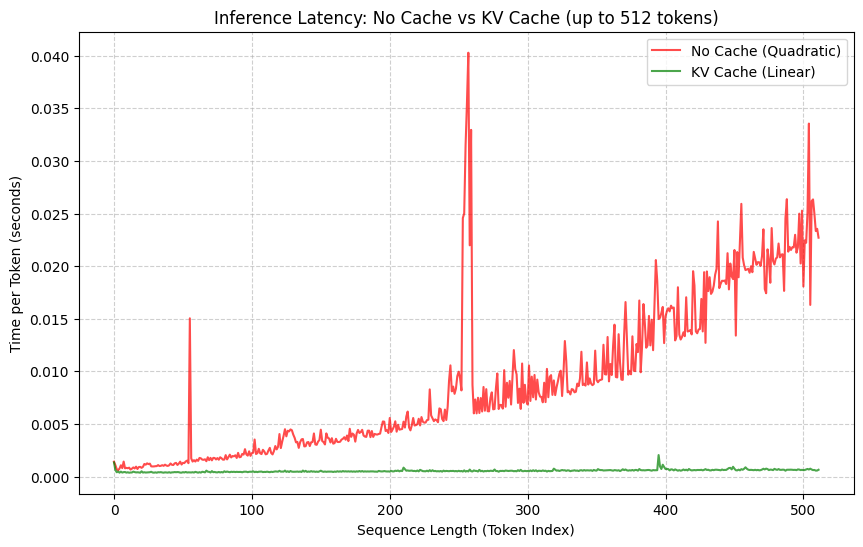

In [68]:
import time
import matplotlib.pyplot as plt
import torch

def benchmark_inference(model, input_ids, max_len=512, use_cache=True):
    current_pos_vectors = input_ids
    past_kv = None
    step_times = []

    # 確保不計算梯度，減少干擾
    model.eval()
    with torch.no_grad():
        for i in range(max_len):
            torch.cuda.synchronize() if torch.cuda.is_available() else None
            start_time = time.perf_counter()

            if use_cache:
                # KV Cache 模式：只傳入最新的一筆
                step_input = current_pos_vectors[:, -1:, :] if i > 0 else current_pos_vectors
                output, _, past_kv = model(step_input, past_kv=past_kv)
            else:
                # 全量重算模式：每次都傳入目前所有的序列
                output, _, _ = model(current_pos_vectors)

            # 模擬生成下一個 token 的向量
            next_token_vec = output[:, -1:, :]
            current_pos_vectors = torch.cat([current_pos_vectors, next_token_vec], dim=1)

            torch.cuda.synchronize() if torch.cuda.is_available() else None
            end_time = time.perf_counter()

            # 記錄這一小步（生成一個 token）花的時間
            step_times.append(end_time - start_time)

    return step_times

# 1. 準備環境
d_model, n_heads, d_ff = 128, 8, 512
test_model = TransformerBlock(d_model, n_heads, d_ff)
initial_prompt = torch.randn(1, 1, d_model) # 從 1 個字開始生
MAX_GEN = 512

# 2. 開始測試
print("正在測試全量重算模式 (No Cache)...")
no_cache_times = benchmark_inference(test_model, initial_prompt, max_len=MAX_GEN, use_cache=False)

print("正在測試 KV Cache 模式...")
kv_cache_times = benchmark_inference(test_model, initial_prompt, max_len=MAX_GEN, use_cache=True)

# 3. 繪製圖表
plt.figure(figsize=(10, 6))
plt.plot(no_cache_times, label='No Cache (Quadratic)', color='red', alpha=0.7)
plt.plot(kv_cache_times, label='KV Cache (Linear)', color='green', alpha=0.7)

plt.title(f"Inference Latency: No Cache vs KV Cache (up to {MAX_GEN} tokens)")
plt.xlabel("Sequence Length (Token Index)")
plt.ylabel("Time per Token (seconds)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()